# Chicago TNP: LLM Peak-Continuation Benchmark  
# Chicago TNP：大模型高峰持续性预测基准

This notebook evaluates a narrow question: after the current H3 cell is confirmed as a peak, can a method predict whether the peak remains active 1, 3, or 6 hours later? The benchmark compares deterministic baselines, a gradient-boosting model, and an OpenAI model on the same balanced 2024 cohorts.  
本 Notebook 评估一个明确问题：当前 H3 单元已确认处于高峰后，模型能否判断 1、3 或 6 小时后高峰仍然持续。实验在相同的 2024 平衡样本上比较确定性基线、梯度提升模型与 OpenAI 模型。

## Reproducible configuration / 可复现配置

- Training-only baselines use 2022-2023; evaluation cases come from 2024. / 基线只使用 2022-2023，评估案例来自 2024。
- OpenAI credentials are entered at runtime and are never stored in the notebook. / OpenAI 凭据在运行时输入，不写入 Notebook。
- Set `CHICAGO_TNP_PROJECT_DIR` and the `MATRIXONE_*` environment variables before execution. / 运行前配置项目目录与 MatrixOne 环境变量。
- The LLM receives compact measured summaries, not the full trip table. / 大模型接收紧凑的观测摘要，而不是完整行程表。


## 0. Install dependencies / 安装依赖

Run once if packages are missing.

如果缺少包，运行下一格一次即可。


In [1]:
# Cell 1 - Install dependencies / 安装依赖
%pip install -q -U pandas numpy matplotlib scikit-learn lightgbm pymysql holidays openai pyarrow


## 1. Enter the API key safely / 安全输入 API key

The key is stored only in the active Jupyter kernel. It is not written to the notebook or exported files. Input is hidden.

key 只保存在当前 Jupyter kernel，不会写入 Notebook 或输出文件。输入时不会显示。


In [2]:
# Cell 2 - Enter OpenAI API key for this kernel / 为当前 kernel 输入 API key

import os
from getpass import getpass

if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass(
        "请输入 OpenAI API key（输入不会显示）: "
    )

print("OPENAI_API_KEY 已载入当前 Jupyter kernel。")


OPENAI_API_KEY 已载入当前 Jupyter kernel。


## 2. Imports and configuration / 导入包和配置

The smoke run sends 20 cases for each horizon, or 60 API requests in total. Use it first. The full run uses 150 cases for each horizon.

smoke run 对每个预测长度发送 20 个案例，一共 60 次 API 请求。先运行 smoke；确认后再改为 full。


In [3]:
from getpass import getpass
# Cell 3 - Imports and configuration / 导入包和配置

from pathlib import Path
from datetime import date, timedelta
import calendar
import json
import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymysql
import holidays
import lightgbm as lgb

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

# Portable project configuration / 可移植项目配置
PROJECT_DIR = Path(
    os.getenv("CHICAGO_TNP_PROJECT_DIR", str(Path.cwd()))
).expanduser().resolve()
PREVIOUS_CACHE_DIR = PROJECT_DIR / "notebook_outputs_hourly_sensitivity_flow_spatial" / "cache"
OUTPUT_DIR = PROJECT_DIR / "notebook_outputs_llm_peak_continuation"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MO_HOST = os.getenv("MATRIXONE_HOST", "127.0.0.1")
MO_PORT = int(os.getenv("MATRIXONE_PORT", "6001"))
MO_USER = os.getenv("MATRIXONE_USER", "root")
MO_PASSWORD = os.getenv("MATRIXONE_PASSWORD") or getpass("MatrixOne password / MatrixOne 密码: ")
MO_DB = os.getenv("MATRIXONE_DATABASE", "chicago_tnp")
ANALYSIS_TABLE = "unified_trips_h3_res9"

TRAIN_END = pd.Timestamp("2024-01-01")
FORECAST_HORIZONS = [1, 3, 6]
HIGH_Z_THRESHOLD = 3.0
MIN_PEAK_COUNT = 100
RANDOM_STATE = 42

# Start with 60 total API requests. / 第一次只跑 60 次 API 请求。
API_MODE = "smoke"  # "smoke" or "full"
SMOKE_CASES_PER_HORIZON = 20
FULL_CASES_PER_HORIZON = 150
RUN_OPENAI_API = True
API_PAUSE_SECONDS = 0.15
OPENAI_MODEL = "gpt-5-mini"

# GBM only learns from peak-start observations in 2022-2023.
# GBM 只用 2022-2023 中当前已高峰的样本训练。
GBM_TRAIN_MAX_ROWS = 50_000

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

print("Output directory:", OUTPUT_DIR)
print("API mode:", API_MODE)
print("Cases per horizon:", SMOKE_CASES_PER_HORIZON if API_MODE == "smoke" else FULL_CASES_PER_HORIZON)
print("Model:", OPENAI_MODEL)


Matplotlib is building the font cache; this may take a moment.


Output directory: <project_dir>/notebook_outputs_llm_peak_continuation
API mode: smoke
Cases per horizon: 20
Model: gpt-5-mini


## 3. Connect to MatrixOne and load the validated hourly cache / 连接 MatrixOne 并读取已验证的小时缓存

The earlier notebook already built the top-50 H3 hourly grid. This notebook reuses that cache instead of re-running a large fact-table query.

之前的 Notebook 已建立 top-50 H3 小时网格。本 Notebook 直接复用缓存，不重复运行大型事实表查询。


In [4]:
# Cell 4 - MatrixOne helpers and hourly cache / MatrixOne 工具和小时缓存

def get_conn(database=MO_DB):
    """Open a MatrixOne connection. / 创建 MatrixOne 连接。"""
    return pymysql.connect(
        host=MO_HOST, port=MO_PORT, user=MO_USER, password=MO_PASSWORD,
        database=database, charset="utf8mb4", autocommit=True,
    )


def query_df(sql, params=None):
    """Run a SQL query and return a pandas DataFrame. / 执行 SQL 查询并返回 pandas DataFrame。"""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        return pd.read_sql_query(sql, conn, params=params)


conn = get_conn()
source_check = query_df(f"SELECT COUNT(*) AS rows_h3 FROM {ANALYSIS_TABLE};")
display(source_check)

hourly_cache = PREVIOUS_CACHE_DIR / "hourly_complete_grid.pkl"
if not hourly_cache.exists():
    raise FileNotFoundError(
        f"Missing hourly cache: {hourly_cache}\n"
        "Please run the hourly sensitivity/flow/spatial notebook first.\n"
        "请先运行上一份小时级敏感度、流动、空间扩散 Notebook。"
    )

hourly = pd.read_pickle(hourly_cache)
hourly["h3"] = hourly["h3"].astype(str)
hourly["d"] = pd.to_datetime(hourly["d"])
hourly["timestamp"] = pd.to_datetime(hourly["timestamp"])
hourly["hour"] = hourly["hour"].astype(int)

required_columns = {
    "h3", "d", "timestamp", "hour", "pickup_count", "dropoff_count", "neighbor_pickup_count"
}
missing = sorted(required_columns - set(hourly.columns))
if missing:
    raise RuntimeError(f"Missing hourly cache columns / 小时缓存缺列: {missing}")

print("Hourly rows / 小时行数:", len(hourly))
print("H3 cells / H3 格子数:", hourly["h3"].nunique())
print("Date range / 日期范围:", hourly["d"].min().date(), "->", hourly["d"].max().date())


,rows_h3
0,243479296


Hourly rows / 小时行数: 1315200
H3 cells / H3 格子数: 50
Date range / 日期范围: 2022-01-01 -> 2024-12-31


## 4. Build a training-only peak baseline / 用训练期建立高峰基线

A high peak is defined relative to its own H3, weekday, and hour. A count of 200 may be normal for one H3 and exceptional for another.

高峰按每个 H3 自己的星期几和小时基线定义。200 单对某些区域是正常，对另一些区域则是异常。


In [5]:
# Cell 5 - Baseline, current peak state, and lag features / 基线、当前高峰状态和滞后特征

frame = hourly.copy().sort_values(["h3", "timestamp"]).reset_index(drop=True)
frame["month"] = frame["d"].dt.month.astype("int8")
frame["day_of_year"] = frame["d"].dt.dayofyear.astype("int16")
frame["dow_mon0"] = frame["d"].dt.dayofweek.astype("int8")
frame["dow_sun0"] = ((frame["dow_mon0"] + 1) % 7).astype("int8")
frame["is_weekend"] = (frame["dow_mon0"] >= 5).astype("int8")
us_holidays = holidays.US(years=[2022, 2023, 2024])
frame["is_holiday"] = frame["d"].dt.date.map(lambda x: int(x in us_holidays)).astype("int8")

def nth_weekday(year, month, weekday, n):
    """Return the nth requested weekday in a month. / 返回某月第 n 个指定星期日期。"""
    first = date(year, month, 1)
    return first + timedelta(days=((weekday - first.weekday()) % 7) + 7 * (n - 1))

dst_days = {nth_weekday(y, 3, calendar.SUNDAY, 2) for y in [2022, 2023, 2024]}
frame["is_dst_missing_hour"] = (
    frame["d"].dt.date.isin(dst_days) & (frame["hour"] == 2)
).astype("int8")

train = frame[frame["timestamp"] < TRAIN_END]
baseline = train.groupby(["h3", "dow_sun0", "hour"], as_index=False).agg(
    expected_pickup=("pickup_count", "mean"),
    std_pickup=("pickup_count", "std"),
    expected_dropoff=("dropoff_count", "mean"),
    std_dropoff=("dropoff_count", "std"),
    expected_neighbor=("neighbor_pickup_count", "mean"),
    std_neighbor=("neighbor_pickup_count", "std"),
)
for col in ["std_pickup", "std_dropoff", "std_neighbor"]:
    baseline[col] = baseline[col].replace(0, np.nan).fillna(1.0).clip(lower=1.0)

frame = frame.merge(baseline, on=["h3", "dow_sun0", "hour"], how="left")
frame["pickup_z"] = (frame["pickup_count"] - frame["expected_pickup"]) / frame["std_pickup"]
frame["dropoff_z"] = (frame["dropoff_count"] - frame["expected_dropoff"]) / frame["std_dropoff"]
frame["neighbor_z"] = (frame["neighbor_pickup_count"] - frame["expected_neighbor"]) / frame["std_neighbor"]
frame["is_high_peak"] = (
    (frame["pickup_count"] >= MIN_PEAK_COUNT) & (frame["pickup_z"] >= HIGH_Z_THRESHOLD)
).astype("int8")
frame["peak_threshold_current_hour"] = np.maximum(
    MIN_PEAK_COUNT,
    frame["expected_pickup"] + HIGH_Z_THRESHOLD * frame["std_pickup"],
)
frame["net_flow"] = frame["dropoff_count"] - frame["pickup_count"]
frame["zone_id"] = frame["h3"].astype("category").cat.codes.astype("int16")

g = frame.groupby("h3", sort=False)
frame["delta_z_1h"] = g["pickup_z"].diff()
frame["z_velocity_3h"] = g["delta_z_1h"].transform(lambda s: s.rolling(3, min_periods=1).mean())
frame["peak_age_hours"] = 0
previous_peak = g["is_high_peak"].shift(1)
previous_timestamp = g["timestamp"].shift(1)
run_break = ((frame["is_high_peak"] != previous_peak) | (
    frame["timestamp"] != previous_timestamp + pd.Timedelta(hours=1)
)).astype("int32")
frame["peak_run_id"] = run_break.groupby(frame["h3"]).cumsum()
is_peak = frame["is_high_peak"] == 1
frame.loc[is_peak, "peak_age_hours"] = (
    frame.loc[is_peak].groupby(["h3", "peak_run_id"]).cumcount().add(1).astype("int16")
)

for lag in [1, 2, 3, 6, 24, 168]:
    frame[f"pickup_lag_{lag}h"] = g["pickup_count"].shift(lag)
    frame[f"dropoff_lag_{lag}h"] = g["dropoff_count"].shift(lag)
    frame[f"neighbor_lag_{lag}h"] = g["neighbor_pickup_count"].shift(lag)
for window in [3, 6, 24]:
    frame[f"pickup_roll_mean_{window}h"] = g["pickup_count"].transform(
        lambda s: s.shift(1).rolling(window, min_periods=max(2, window // 2)).mean()
    )

for horizon in FORECAST_HORIZONS:
    frame[f"target_pickup_h{horizon}"] = g["pickup_count"].shift(-horizon)
    frame[f"target_peak_h{horizon}"] = g["is_high_peak"].shift(-horizon)
    frame[f"target_timestamp_h{horizon}"] = g["timestamp"].shift(-horizon)
    frame[f"target_dst_h{horizon}"] = g["is_dst_missing_hour"].shift(-horizon)
    frame[f"target_peak_threshold_h{horizon}"] = g["peak_threshold_current_hour"].shift(-horizon)
    frame[f"naive_weekly_h{horizon}"] = g["pickup_count"].shift(168 - horizon)

print("2024 current high-peak hours / 2024 当前高峰小时数:", int(((frame["timestamp"] >= TRAIN_END) & (frame["is_high_peak"] == 1)).sum()))


2024 current high-peak hours / 2024 当前高峰小时数: 4282


## 5. Create horizon-specific continuation cohorts / 为每个预测长度建立高峰持续案例

Every row in every cohort starts from a confirmed current peak. For each horizon, we balance cases where the future peak continues and cases where it ends.

每个案例的当前小时都已经确认是高峰。对于每个预测长度，分别平衡“未来仍高峰”和“未来已回落”的案例。


In [6]:
# Cell 6 - Select current-peak continuation cohorts / 选择当前高峰的持续预测案例

def sample_continuation_cases(horizon, n_cases, seed=RANDOM_STATE):
    """Build a balanced continuation cohort for one horizon. / 为一个预测跨度构造平衡的高峰持续样本。"""
    valid = (
        (frame["timestamp"] >= TRAIN_END)
        & (frame["timestamp"] < pd.Timestamp("2025-01-01"))
        & (frame["is_high_peak"] == 1)
        & frame[f"target_pickup_h{horizon}"].notna()
        & (frame["is_dst_missing_hour"] == 0)
        & (frame[f"target_dst_h{horizon}"].fillna(0) == 0)
    )
    pool = frame.loc[valid].copy()
    continued = pool[pool[f"target_peak_h{horizon}"] == 1]
    ended = pool[pool[f"target_peak_h{horizon}"] == 0]
    n_each = min(n_cases // 2, len(continued), len(ended))
    result = pd.concat([
        continued.sample(n=n_each, random_state=seed + horizon),
        ended.sample(n=n_each, random_state=seed + 100 + horizon),
    ], ignore_index=True)
    result["forecast_horizon"] = horizon
    result = result.sample(frac=1, random_state=seed + 200 + horizon).reset_index(drop=True)
    result["case_id"] = [f"h{horizon}_peak_case_{i:04d}" for i in range(1, len(result) + 1)]
    return result, {"horizon": horizon, "pool_rows": len(pool), "continued": len(continued), "ended": len(ended), "selected": len(result)}


n_cases = SMOKE_CASES_PER_HORIZON if API_MODE == "smoke" else FULL_CASES_PER_HORIZON
cohorts = []
cohort_summary = []
for horizon in FORECAST_HORIZONS:
    cohort, summary = sample_continuation_cases(horizon, n_cases)
    cohorts.append(cohort)
    cohort_summary.append(summary)

cases = pd.concat(cohorts, ignore_index=True)
cohort_summary = pd.DataFrame(cohort_summary)
display(cohort_summary)
print("Total API cases / 总 API 案例:", len(cases))

cohort_summary.to_csv(OUTPUT_DIR / f"cohort_summary_{API_MODE}.csv", index=False)
cases[["case_id", "forecast_horizon", "h3", "timestamp", "pickup_count", "pickup_z", "peak_age_hours"] + [f"target_peak_h{h}" for h in FORECAST_HORIZONS]].to_csv(
    OUTPUT_DIR / f"selected_current_peak_cases_{API_MODE}.csv", index=False
)


,horizon,pool_rows,continued,ended,selected
0,1,4264,1688,2576,20
1,3,4221,798,3423,20
2,6,4169,371,3798,20


Total API cases / 总 API 案例: 60


## 6. Build compact prompts with deterministic evidence / 使用确定性证据建立紧凑 prompt

The LLM does not decide whether the current hour is a peak. Python already proved it. The LLM can only cite signal IDs calculated from the current and historical data.

LLM 不负责判断当前是否高峰，这一步已经由 Python 完成。它只能引用代码计算出的信号编号。


In [7]:
# Cell 7 - Prompt payloads and deterministic evidence / prompt 数据包和确定性证据

pickup_lookup = frame.set_index(["h3", "timestamp"])["pickup_count"]

def safe_num(value, digits=3):
    """Convert a value to a compact JSON-safe number. / 将数值转成适合 JSON 的紧凑格式。"""
    if pd.isna(value) or np.isinf(value):
        return None
    return round(float(value), digits)

def history_24(h3_value, ts):
    """Return the preceding 24 hourly observations for one H3 cell. / 返回一个 H3 单元此前 24 小时的观测。"""
    return [
        int(pickup_lookup.get((str(h3_value), ts - pd.Timedelta(hours=offset)), 0))
        for offset in range(23, -1, -1)
    ]

def deterministic_evidence(row):
    """Create reproducible evidence labels from measured signals. / 根据观测指标生成可复现的证据标签。"""
    signals = {"S0_current_confirmed_peak": "当前小时已按统计规则确认是高峰。"}
    if row["delta_z_1h"] >= 1:
        signals["S1_rising_fast"] = "当前 z-score 比上一小时至少上升 1。"
    if row["z_velocity_3h"] >= 0.5:
        signals["S2_recent_rise"] = "最近 3 小时异常程度总体在上升。"
    if row["peak_age_hours"] >= 2:
        signals["S3_peak_already_persistent"] = "当前高峰已经连续至少 2 小时。"
    if row["neighbor_z"] >= 2:
        signals["S4_neighbor_pressure"] = "周边一环 H3 客流也明显高于正常。"
    if row["dropoff_z"] >= 2:
        signals["S5_dropoff_pressure"] = "当前区域 dropoff 也明显高于正常。"
    if row["pickup_lag_168h"] >= row["pickup_count"] * 0.9:
        signals["S6_weekly_pattern_high"] = "上周同一小时客流也接近当前高峰水平。"
    return signals

def make_payload(row):
    """Build one compact LLM input payload. / 构造一条紧凑的大模型输入。"""
    h = int(row["forecast_horizon"])
    evidence = deterministic_evidence(row)
    return {
        "case_id": row["case_id"],
        "forecast_horizon_hours": h,
        "zone_id": int(row["zone_id"]),
        "calendar": {
            "weekday_mon0": int(row["dow_mon0"]),
            "month": int(row["month"]),
            "hour_just_completed": int(row["hour"]),
            "is_weekend": bool(row["is_weekend"]),
            "is_us_holiday": bool(row["is_holiday"]),
        },
        "confirmed_current_peak": {
            "pickup_count": int(row["pickup_count"]),
            "pickup_z_score": safe_num(row["pickup_z"]),
            "current_peak_age_hours": int(row["peak_age_hours"]),
            "dropoff_count": int(row["dropoff_count"]),
            "dropoff_z_score": safe_num(row["dropoff_z"]),
            "neighbor_pickup_count": int(row["neighbor_pickup_count"]),
            "neighbor_z_score": safe_num(row["neighbor_z"]),
            "z_change_from_previous_hour": safe_num(row["delta_z_1h"]),
            "z_velocity_recent_3h": safe_num(row["z_velocity_3h"]),
        },
        "history": {
            "pickup_counts_last_24_completed_hours": history_24(row["h3"], row["timestamp"]),
            "pickup_same_hour_1_week_ago": safe_num(row["pickup_lag_168h"], 0),
            "pickup_mean_previous_6h": safe_num(row["pickup_roll_mean_6h"]),
            "pickup_mean_previous_24h": safe_num(row["pickup_roll_mean_24h"]),
        },
        # Provide only the decision threshold, not future expected count and standard deviation.
        # 只提供未来高峰所需的门槛，不直接提供未来正常均值和标准差。
        "future_peak_rule": {
            "peak_required_pickup_count": int(np.ceil(row[f"target_peak_threshold_h{h}"])),
            "definition": "A continued peak means predicted pickups are at least this count.",
        },
        "eligible_evidence": evidence,
    }

payloads = {row["case_id"]: make_payload(row) for _, row in cases.iterrows()}
payload_path = OUTPUT_DIR / f"llm_peak_continuation_payloads_{API_MODE}.jsonl"
with payload_path.open("w", encoding="utf-8") as f:
    for payload in payloads.values():
        f.write(json.dumps(payload, ensure_ascii=False) + "\n")

print(json.dumps(payloads[cases.iloc[0]["case_id"]], ensure_ascii=False, indent=2))
print("Payload file / prompt 文件:", payload_path)


{
  "case_id": "h1_peak_case_0001",
  "forecast_horizon_hours": 1,
  "zone_id": 10,
  "calendar": {
    "weekday_mon0": 0,
    "month": 1,
    "hour_just_completed": 3,
    "is_weekend": false,
    "is_us_holiday": true
  },
  "confirmed_current_peak": {
    "pickup_count": 176,
    "pickup_z_score": 17.175,
    "current_peak_age_hours": 4,
    "dropoff_count": 191,
    "dropoff_z_score": 13.788,
    "neighbor_pickup_count": 0,
    "neighbor_z_score": 0.0,
    "z_change_from_previous_hour": -12.633,
    "z_velocity_recent_3h": 4.003
  },
  "history": {
    "pickup_counts_last_24_completed_hours": [
      31,
      19,
      40,
      46,
      63,
      129,
      253,
      311,
      304,
      242,
      224,
      324,
      361,
      390,
      379,
      509,
      543,
      529,
      422,
      355,
      235,
      279,
      278,
      176
    ],
    "pickup_same_hour_1_week_ago": 2.0,
    "pickup_mean_previous_6h": 349.667,
    "pickup_mean_previous_24h": 262.5
  },
  "fut

## 7. Train a current-peak GBM comparator / 训练当前高峰条件下的 GBM 对照模型

GBM is trained only on 2022-2023 observations where the current hour was already a peak. This makes its training situation match the API cases.

GBM 只用 2022-2023 中当前已经是高峰的小时训练，保证它与 API 案例面对相同的问题。


In [8]:
# Cell 8 - Train GBM conditional on current peak / 在当前高峰条件下训练 GBM

gbm_features = [
    "zone_id", "hour", "dow_mon0", "month", "day_of_year", "is_weekend", "is_holiday",
    "pickup_count", "dropoff_count", "neighbor_pickup_count", "net_flow",
    "expected_pickup", "std_pickup", "pickup_z", "dropoff_z", "neighbor_z",
    "delta_z_1h", "z_velocity_3h", "peak_age_hours",
    "pickup_lag_1h", "pickup_lag_2h", "pickup_lag_3h", "pickup_lag_6h", "pickup_lag_24h", "pickup_lag_168h",
    "dropoff_lag_1h", "dropoff_lag_3h", "neighbor_lag_1h", "neighbor_lag_3h",
    "pickup_roll_mean_3h", "pickup_roll_mean_6h", "pickup_roll_mean_24h",
]

def prepare_x(data, medians=None):
    """Prepare numeric model features with training medians. / 使用训练期中位数准备数值特征。"""
    x = data[gbm_features].replace([np.inf, -np.inf], np.nan)
    if medians is None:
        medians = x.median()
    return x.fillna(medians).astype("float32"), medians

gbm_predictions = []
for horizon in FORECAST_HORIZONS:
    valid_train = (
        (frame["timestamp"] < TRAIN_END)
        & (frame["is_high_peak"] == 1)
        & frame[f"target_pickup_h{horizon}"].notna()
        & (frame["is_dst_missing_hour"] == 0)
        & (frame[f"target_dst_h{horizon}"].fillna(0) == 0)
    )
    train_rows = frame.loc[valid_train].copy()
    if len(train_rows) > GBM_TRAIN_MAX_ROWS:
        train_rows = train_rows.sample(GBM_TRAIN_MAX_ROWS, random_state=RANDOM_STATE + horizon)
    x_train, medians = prepare_x(train_rows)
    model = lgb.LGBMRegressor(
        objective="regression_l1", n_estimators=260, learning_rate=0.05,
        num_leaves=31, min_child_samples=30, reg_lambda=1.0,
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1,
    )
    started = time.time()
    model.fit(x_train, train_rows[f"target_pickup_h{horizon}"].astype("float32"))
    test_rows = cases[cases["forecast_horizon"] == horizon].copy()
    x_test, _ = prepare_x(test_rows, medians)
    test_rows["gbm_predicted_pickups"] = np.clip(model.predict(x_test), 0, None)
    test_rows["gbm_fit_seconds"] = time.time() - started
    gbm_predictions.append(test_rows)
    print(f"h+{horizon}: train rows={len(train_rows):,}, test cases={len(test_rows)}")

benchmark_cases = pd.concat(gbm_predictions, ignore_index=True)


h+1: train rows=3,053, test cases=20
h+3: train rows=3,053, test cases=20
h+6: train rows=3,045, test cases=20


## 8. Score traditional baselines / 评分传统基线

The count prediction is converted to a continued-peak decision using the same future threshold given to the LLM.

所有方法都使用相同的未来高峰门槛，把客流预测转换为“是否仍高峰”的判断。


In [9]:
# Cell 9 - Baseline metrics / 基线指标

def count_metrics(y_true, y_pred):
    """Calculate count-forecast metrics. / 计算客流数量预测指标。"""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 0, None)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }

def class_metrics(y_true, y_pred):
    """Calculate binary continuation metrics. / 计算二分类高峰持续指标。"""
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }

baseline_rows = []
for horizon, sub in benchmark_cases.groupby("forecast_horizon"):
    y_count = sub[f"target_pickup_h{horizon}"].to_numpy()
    y_peak = sub[f"target_peak_h{horizon}"].astype(int).to_numpy()
    threshold = sub[f"target_peak_threshold_h{horizon}"].to_numpy()
    predictors = {
        "Naive current-hour / 当前小时": sub["pickup_count"].to_numpy(),
        "Naive last-week target / 上周同目标小时": sub[f"naive_weekly_h{horizon}"].fillna(sub["pickup_count"]).to_numpy(),
        "GBM current-peak / GBM 当前高峰": sub["gbm_predicted_pickups"].to_numpy(),
    }
    for name, prediction in predictors.items():
        row = {"method": name, "horizon_hours": int(horizon), "test_cases": len(sub)}
        row.update(count_metrics(y_count, prediction))
        row.update(class_metrics(y_peak, (prediction >= threshold).astype(int)))
        baseline_rows.append(row)

baseline_metrics = pd.DataFrame(baseline_rows).sort_values(["horizon_hours", "MAE"])
display(baseline_metrics.round(4))
baseline_metrics.to_csv(OUTPUT_DIR / f"baseline_metrics_current_peak_{API_MODE}.csv", index=False)


,method,horizon_hours,test_cases,MAE,RMSE,R2,accuracy,precision,recall,F1
0,Naive current-hour / 当前小时,1,20,63.9000,109.6038,0.7065,0.60,0.5625,0.9,0.6923
2,GBM current-peak / GBM 当前高峰,1,20,71.2690,142.5247,0.5038,0.50,0.5000,0.2,0.2857
1,Naive last-week target / 上周同目标小时,1,20,136.2000,201.4599,0.0086,0.45,0.0000,0.0,0.0000
5,GBM current-peak / GBM 当前高峰,3,20,34.3772,46.9658,0.8716,0.80,1.0000,0.6,0.7500
4,Naive last-week target / 上周同目标小时,3,20,94.7500,142.6550,-0.1845,0.50,0.0000,0.0,0.0000
3,Naive current-hour / 当前小时,3,20,109.2500,167.2329,-0.6278,0.50,0.5000,0.8,0.6154
8,GBM current-peak / GBM 当前高峰,6,20,57.2871,87.8124,0.9012,0.70,1.0000,0.4,0.5714
7,Naive last-week target / 上周同目标小时,6,20,78.8000,151.6845,0.7052,0.55,1.0000,0.1,0.1818
6,Naive current-hour / 当前小时,6,20,174.5500,238.2821,0.2726,0.25,0.3333,0.5,0.4000


## 9. Configure the OpenAI client and structured response / 配置 OpenAI 客户端与结构化输出

The notebook supports both the newer Responses API and older Chat Completions SDKs.

Notebook 同时兼容新版 Responses API 和早期实现 Chat Completions SDK。


In [10]:
import os
# Cell 10 - OpenAI client and safe response schema / OpenAI 客户端和安全输出格式

if not RUN_OPENAI_API:
    raise RuntimeError("Set RUN_OPENAI_API=True in Cell 3 before running the API benchmark.")
if not os.environ.get("OPENAI_API_KEY"):
    raise EnvironmentError("Run Cell 2 to enter OPENAI_API_KEY for this kernel.")

from openai import OpenAI
client = OpenAI()
print("OpenAI client ready. / OpenAI 客户端已就绪。")

EVIDENCE_IDS = [
    "S0_current_confirmed_peak", "S1_rising_fast", "S2_recent_rise",
    "S3_peak_already_persistent", "S4_neighbor_pressure", "S5_dropoff_pressure",
    "S6_weekly_pattern_high",
]

RESPONSE_SCHEMA = {
    "type": "object",
    "properties": {
        "predicted_pickups": {"type": "integer"},
        "will_remain_peak": {"type": "boolean"},
        "peak_probability": {"type": "number"},
        "evidence_ids": {"type": "array", "items": {"type": "string", "enum": EVIDENCE_IDS}},
        "short_explanation": {"type": "string"},
    },
    "required": ["predicted_pickups", "will_remain_peak", "peak_probability", "evidence_ids", "short_explanation"],
    "additionalProperties": False,
}

SYSTEM_PROMPT = """
You forecast one confirmed current pickup peak for one anonymized Chicago zone.
The only question is whether it remains a peak at the requested future horizon.
Use only the supplied JSON. Do not use web knowledge or invent events.
The current hour is already confirmed to be a peak.
The future peak rule gives the minimum count needed for a continued peak.
You may cite only evidence IDs listed in eligible_evidence.
Return one JSON object matching the required schema. Do not reveal hidden reasoning.
""".strip()

def call_openai(payload):
    """Call the OpenAI API with a structured response schema. / 使用结构化输出格式调用 OpenAI API。"""
    started = time.time()
    if hasattr(client, "responses"):
        response = client.responses.create(
            model=OPENAI_MODEL,
            input=[
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": json.dumps(payload, ensure_ascii=False)},
            ],
            text={"format": {"type": "json_schema", "name": "peak_continuation", "strict": True, "schema": RESPONSE_SCHEMA}},
        )
        result = json.loads(response.output_text)
        usage = getattr(response, "usage", None)
    else:
        completion = client.chat.completions.create(
            model=OPENAI_MODEL,
            messages=[
                {"role": "system", "content": SYSTEM_PROMPT + "\nSchema: " + json.dumps(RESPONSE_SCHEMA)},
                {"role": "user", "content": json.dumps(payload, ensure_ascii=False)},
            ],
            response_format={"type": "json_object"},
        )
        result = json.loads(completion.choices[0].message.content)
        usage = getattr(completion, "usage", None)

    allowed = set(payload["eligible_evidence"])
    cited = set(result.get("evidence_ids", []))
    if not cited.issubset(allowed):
        raise ValueError(f"LLM cited unavailable evidence: {sorted(cited - allowed)}")
    result["predicted_pickups"] = max(0, int(result["predicted_pickups"]))
    result["peak_probability"] = float(np.clip(float(result["peak_probability"]), 0, 1))
    return result, time.time() - started, usage


OpenAI client ready. / OpenAI 客户端已就绪。


## 10. Test one case before the batch / 先测试一个案例

Inspect this answer before sending the rest. The cited evidence IDs must be a subset of the deterministic signals shown in the payload.

先看一个回答。它引用的信号编号必须来自代码提供的确定性证据。


In [11]:
# Cell 11 - Single-case API smoke test / 单案例 API 测试

first_case_id = benchmark_cases.iloc[0]["case_id"]
single_result, single_latency, single_usage = call_openai(payloads[first_case_id])
print("Case:", first_case_id)
print("Latency seconds:", round(single_latency, 2))
print(json.dumps(single_result, ensure_ascii=False, indent=2))


Case: h1_peak_case_0001
Latency seconds: 14.14
{
  "predicted_pickups": 160,
  "will_remain_peak": true,
  "peak_probability": 0.87,
  "evidence_ids": [
    "S0_current_confirmed_peak",
    "S2_recent_rise",
    "S3_peak_already_persistent",
    "S5_dropoff_pressure"
  ],
  "short_explanation": "当前小时已被确认为高峰 (S0); 最近3小时异常程度总体上升 (S2); 高峰已持续至少2小时 (S3); dropoff 也明显偏高，支持需求持续 (S5)。预测下小时约160次接单，≥规则所需100次，因此很可能仍是高峰（概率0.87）。"
}


## 11. Run the resumable benchmark / 运行可断点续跑的测试

Successful cases are saved one by one. If the kernel stops, rerunning skips only successful cases; prior errors will be retried.

成功结果会逐条保存。若 kernel 中断，重新运行只跳过成功案例；之前错误案例会重试。


In [12]:
# Cell 12 - Run all API cases / 运行全部 API 案例

api_results_path = OUTPUT_DIR / f"openai_current_peak_responses_{OPENAI_MODEL}_{API_MODE}.jsonl"

def successful_ids(path):
    """Load successfully completed case identifiers from cache. / 从缓存读取已成功完成的案例编号。"""
    result = set()
    if path.exists():
        for line in path.read_text(encoding="utf-8").splitlines():
            try:
                item = json.loads(line)
                if item.get("status") == "ok":
                    result.add(item["case_id"])
            except json.JSONDecodeError:
                pass
    return result

done = successful_ids(api_results_path)
remaining = [case_id for case_id in benchmark_cases["case_id"] if case_id not in done]
print(f"Completed: {len(done)}, remaining: {len(remaining)}")

with api_results_path.open("a", encoding="utf-8") as f:
    for n, case_id in enumerate(remaining, start=1):
        try:
            result, latency_seconds, usage = call_openai(payloads[case_id])
            usage_dict = None if usage is None else {
                key: getattr(usage, key, None)
                for key in ["input_tokens", "output_tokens", "total_tokens"]
            }
            record = {"case_id": case_id, "status": "ok", "result": result, "latency_seconds": latency_seconds, "usage": usage_dict}
        except Exception as exc:
            record = {"case_id": case_id, "status": "error", "error": repr(exc)}
            print(f"API error on {case_id}: {exc!r}")
        f.write(json.dumps(record, ensure_ascii=False) + "\n")
        f.flush()
        if n % 10 == 0 or n == len(remaining):
            print(f"Processed {n}/{len(remaining)} new cases")
        time.sleep(API_PAUSE_SECONDS)

print("Saved to / 已保存:", api_results_path)


Completed: 0, remaining: 60
Processed 10/60 new cases
Processed 20/60 new cases
Processed 30/60 new cases
Processed 40/60 new cases
Processed 50/60 new cases
Processed 60/60 new cases
Saved to / 已保存: <project_dir>/notebook_outputs_llm_peak_continuation/openai_current_peak_responses_gpt-5-mini_smoke.jsonl


## 12. Compare LLM with baselines / 比较 LLM 与传统基线

Read count accuracy and continuation classification separately. A method can catch more continued peaks but generate too many false alarms.

数值误差和高峰持续分类要分开看。一个方法可能抓住更多持续高峰，但同时制造更多误报。


In [13]:
# Cell 13 - Evaluate results / 评估结果

response_rows = []
if api_results_path.exists():
    for line in api_results_path.read_text(encoding="utf-8").splitlines():
        item = json.loads(line)
        if item.get("status") == "ok":
            response_rows.append({
                "case_id": item["case_id"],
                **item["result"],
                "latency_seconds": item.get("latency_seconds"),
                "usage": item.get("usage"),
            })

api_df = pd.DataFrame(response_rows)
if api_df.empty:
    raise RuntimeError("No successful API responses. Check Cell 11 and Cell 12.")

evaluation = benchmark_cases.merge(api_df, on="case_id", how="inner")
api_rows = []
for horizon, sub in evaluation.groupby("forecast_horizon"):
    y_count = sub[f"target_pickup_h{horizon}"].to_numpy()
    y_peak = sub[f"target_peak_h{horizon}"].astype(int).to_numpy()
    row = {"method": f"OpenAI {OPENAI_MODEL}", "horizon_hours": int(horizon), "test_cases": len(sub)}
    row.update(count_metrics(y_count, sub["predicted_pickups"].to_numpy()))
    row.update(class_metrics(y_peak, sub["will_remain_peak"].astype(int).to_numpy()))
    row["mean_latency_seconds"] = sub["latency_seconds"].mean()
    api_rows.append(row)

api_metrics = pd.DataFrame(api_rows)
comparison = pd.concat([baseline_metrics, api_metrics], ignore_index=True).sort_values(["horizon_hours", "MAE"])
display(comparison.round(4))
comparison.to_csv(OUTPUT_DIR / f"model_comparison_current_peak_{API_MODE}.csv", index=False)

usage_df = pd.json_normalize(evaluation["usage"]).add_prefix("usage_")
if not usage_df.empty:
    print("Token usage summary / token 用量总结:")
    display(usage_df.describe().round(2))

detail_cols = [
    "case_id", "forecast_horizon", "h3", "timestamp", "pickup_count", "pickup_z", "peak_age_hours",
    "predicted_pickups", "will_remain_peak", "peak_probability", "evidence_ids", "short_explanation",
    "gbm_predicted_pickups", "latency_seconds",
]
for h in FORECAST_HORIZONS:
    detail_cols.extend([f"target_pickup_h{h}", f"target_peak_h{h}"])
details = evaluation[detail_cols].copy()
details.to_csv(OUTPUT_DIR / f"case_level_current_peak_comparison_{API_MODE}.csv", index=False)
display(details.head(10))


,method,horizon_hours,test_cases,MAE,RMSE,R2,accuracy,precision,recall,F1,mean_latency_seconds
0,Naive current-hour / 当前小时,1,20,63.9000,109.6038,0.7065,0.60,0.5625,0.9,0.6923,NaN
9,OpenAI gpt-5-mini,1,20,67.4000,116.2093,0.6701,0.55,0.5294,0.9,0.6667,9.8355
1,GBM current-peak / GBM 当前高峰,1,20,71.2690,142.5247,0.5038,0.50,0.5000,0.2,0.2857,NaN
2,Naive last-week target / 上周同目标小时,1,20,136.2000,201.4599,0.0086,0.45,0.0000,0.0,0.0000,NaN
3,GBM current-peak / GBM 当前高峰,3,20,34.3772,46.9658,0.8716,0.80,1.0000,0.6,0.7500,NaN
10,OpenAI gpt-5-mini,3,20,92.0000,137.0394,-0.0931,0.50,0.5000,0.8,0.6154,12.1492
4,Naive last-week target / 上周同目标小时,3,20,94.7500,142.6550,-0.1845,0.50,0.0000,0.0,0.0000,NaN
5,Naive current-hour / 当前小时,3,20,109.2500,167.2329,-0.6278,0.50,0.5000,0.8,0.6154,NaN
6,GBM current-peak / GBM 当前高峰,6,20,57.2871,87.8124,0.9012,0.70,1.0000,0.4,0.5714,NaN
7,Naive last-week target / 上周同目标小时,6,20,78.8000,151.6845,0.7052,0.55,1.0000,0.1,0.1818,NaN


Token usage summary / token 用量总结:


,usage_input_tokens,usage_output_tokens,usage_total_tokens
count,60.00,60.00,60.00
mean,620.28,768.90,1389.18
std,22.23,134.91,143.19
min,570.00,569.00,1161.00
25%,611.00,664.75,1274.25
50%,613.00,747.50,1377.00
75%,633.25,873.25,1487.25
max,676.00,1100.00,1735.00


,case_id,forecast_horizon,h3,timestamp,pickup_count,pickup_z,peak_age_hours,predicted_pickups,will_remain_peak,peak_probability,evidence_ids,short_explanation,gbm_predicted_pickups,latency_seconds,target_pickup_h1,target_peak_h1,target_pickup_h3,target_peak_h3,target_pickup_h6,target_peak_h6
0,h1_peak_case_0001,1,892664c1a8bffff,2024-01-01 03:00:00,176,17.175091,4,150,True,0.85,"[S0_current_confirmed_peak, S3_peak_already_pe...","当前小时已被确认为高峰且已持续数小时（S0_current_confirmed_peak, ...",74.360565,12.750230,67.0,0.0,50.0,0.0,67.0,0.0
1,h1_peak_case_0002,1,89275934ed3ffff,2024-04-01 22:00:00,623,3.304326,1,640,True,0.87,"[S0_current_confirmed_peak, S1_rising_fast, S2...",基于证据 S0_current_confirmed_peak、S1_rising_fast ...,470.214726,9.883069,556.0,1.0,158.0,0.0,4.0,0.0
2,h1_peak_case_0003,1,892664c1e8fffff,2024-08-22 12:00:00,124,3.048210,1,125,True,0.82,"[S0_current_confirmed_peak, S2_recent_rise]",当前小时已被确认为高峰（124 次），且最近 3 小时异常程度总体上升，预计 1 小时后仍至...,96.769379,8.040270,103.0,0.0,107.0,0.0,88.0,0.0
3,h1_peak_case_0004,1,892664c1e2fffff,2024-12-30 14:00:00,325,3.539651,1,327,True,0.78,"[S0_current_confirmed_peak, S5_dropoff_pressure]",当前小时已确认为高峰 (S0)，且区域 dropoff 也显著高于正常，支持需求持续 (S5...,359.085669,11.008835,318.0,0.0,406.0,0.0,270.0,0.0
4,h1_peak_case_0005,1,89275934ed3ffff,2024-11-30 08:00:00,396,3.340157,1,440,True,0.78,"[S0_current_confirmed_peak, S1_rising_fast]",当前小时已被确认为高峰（396），但持续为高峰需≥422。当前 z-score 较上一小时上...,380.903658,10.087408,403.0,0.0,460.0,1.0,583.0,1.0
5,h1_peak_case_0006,1,892664c1acfffff,2024-05-13 22:00:00,175,4.148500,1,170,True,0.85,"[S0_current_confirmed_peak, S1_rising_fast, S2...",当前小时已确认为高峰（S0）；相比上一小时 z-score 大幅上升（S1），且最近3小时异...,87.449158,24.735042,46.0,0.0,3.0,0.0,2.0,0.0
6,h1_peak_case_0007,1,892664c1b0bffff,2024-03-28 12:00:00,248,3.594972,1,250,True,0.88,"[S0_current_confirmed_peak, S1_rising_fast, S2...",Current hour is a confirmed peak (248) and exc...,195.770567,8.753840,242.0,1.0,220.0,0.0,218.0,0.0
7,h1_peak_case_0008,1,892664c1aa7ffff,2024-05-22 07:00:00,148,3.010763,1,90,False,0.02,[S0_current_confirmed_peak],当前小时已确认为高峰（148 次），但远低于持续高峰所需的 253 次；因此在 1 小时后保...,147.397890,9.780833,257.0,1.0,156.0,0.0,76.0,0.0
8,h1_peak_case_0009,1,89266452183ffff,2024-12-01 18:00:00,269,3.429619,4,269,True,0.82,"[S0_current_confirmed_peak, S3_peak_already_pe...",当前小时已被确认为高峰且该高峰已连续多小时存在；预计下一小时的乘客数将维持在规则要求的最低值...,239.039926,6.704918,177.0,0.0,325.0,1.0,199.0,0.0
9,h1_peak_case_0010,1,892664c1e8fffff,2024-01-22 09:00:00,109,3.043545,1,110,True,0.88,"[S0_current_confirmed_peak, S2_recent_rise, S4...",Current hour is a confirmed peak at 109 pickup...,88.772393,7.687952,106.0,1.0,71.0,0.0,54.0,0.0


## 13. Visualize one continued and one ended peak / 可视化一个持续高峰和一个回落高峰

This chart is useful for explaining the model to a manager: both examples begin from a true high peak, but one continues while the other falls back.

这张图适合向老板解释：两个案例都从真实高峰开始，但一个继续，一个回落。


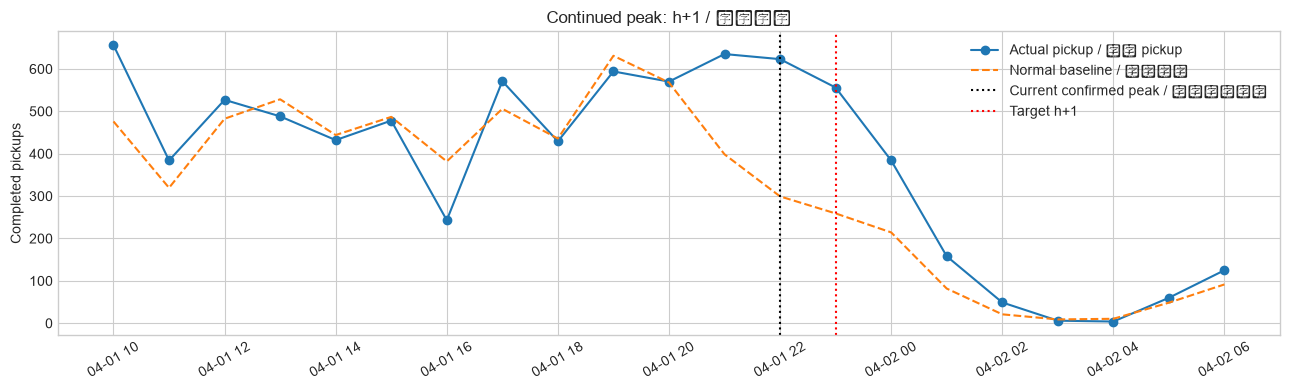

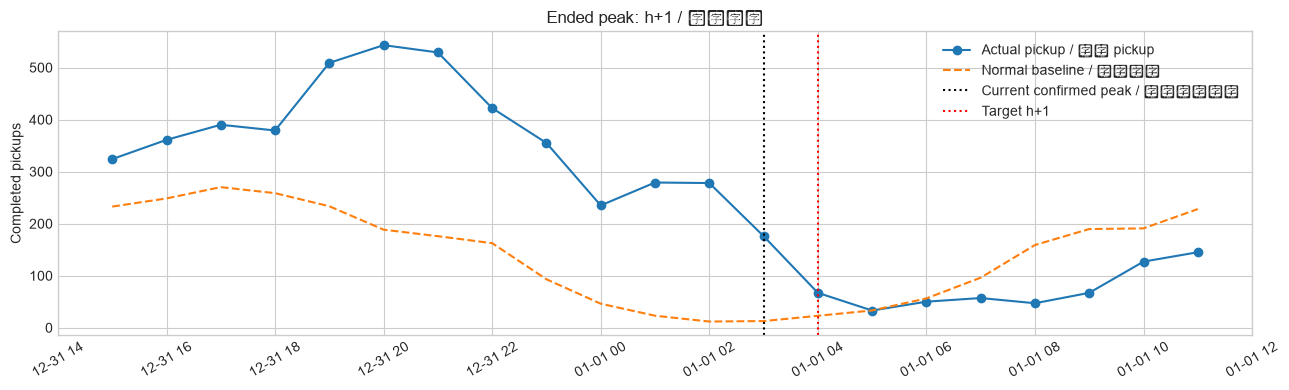

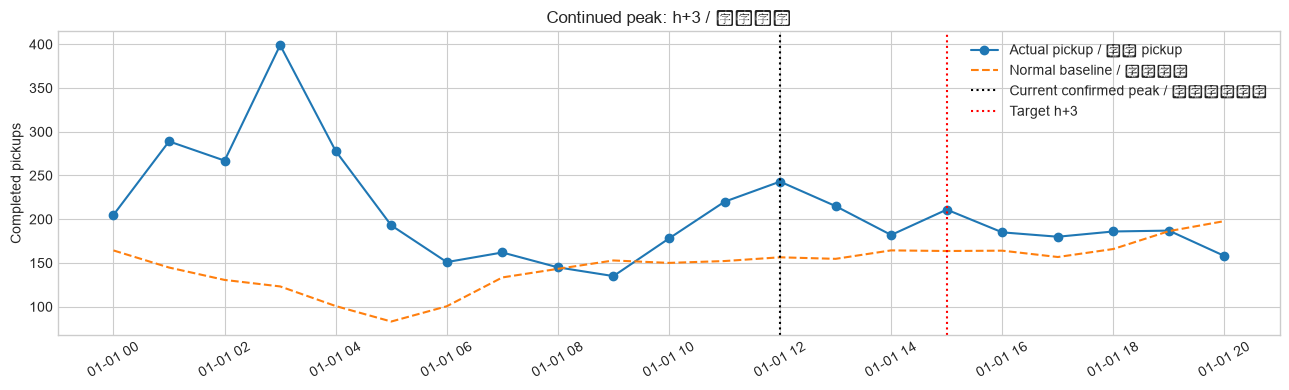

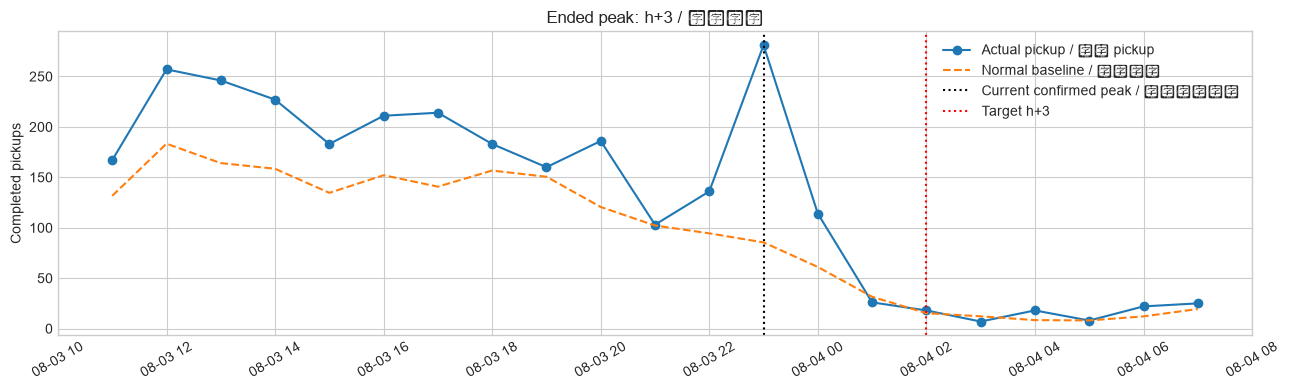

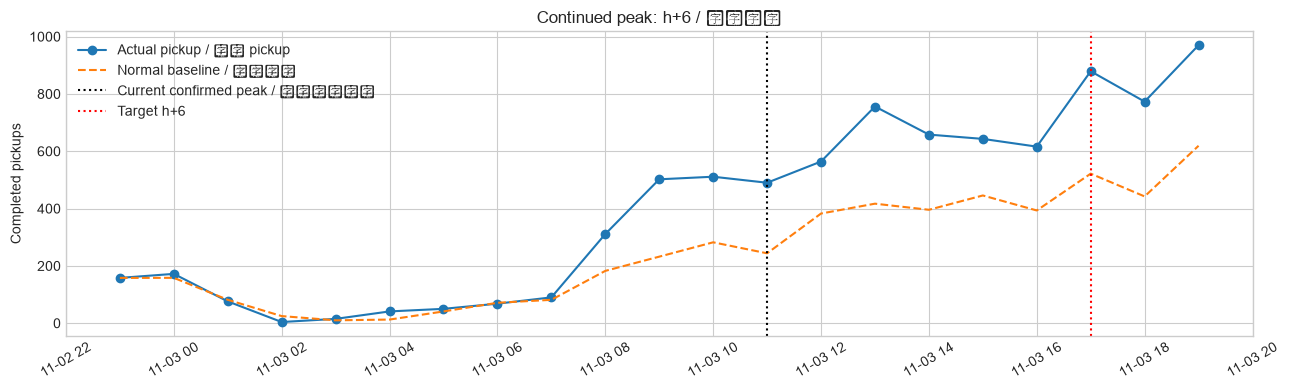

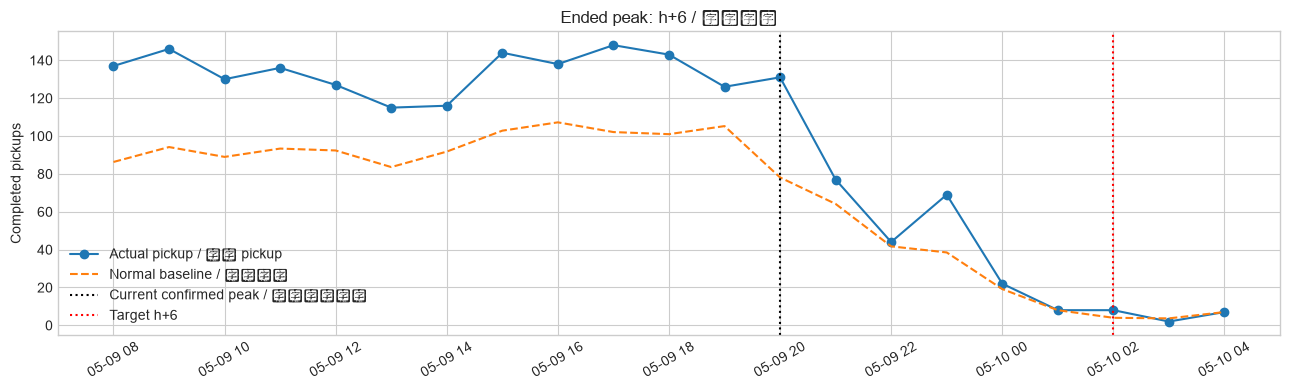

In [14]:
# Cell 14 - Plot continued versus ended peak / 画持续和回落的高峰案例

def plot_case(case_row, title):
    """Plot observed history, forecast horizon, and peak threshold. / 绘制历史观测、预测区间与高峰阈值。"""
    h3_value = case_row["h3"]
    start = pd.Timestamp(case_row["timestamp"])
    horizon = int(case_row["forecast_horizon"])
    sub = frame[(frame["h3"] == h3_value) & frame["timestamp"].between(start - pd.Timedelta(hours=12), start + pd.Timedelta(hours=8))]
    plt.figure(figsize=(13, 4))
    plt.plot(sub["timestamp"], sub["pickup_count"], marker="o", label="Actual pickup / 实际 pickup")
    plt.plot(sub["timestamp"], sub["expected_pickup"], linestyle="--", label="Normal baseline / 正常基线")
    plt.axvline(start, color="black", linestyle=":", label="Current confirmed peak / 当前确认高峰")
    plt.axvline(start + pd.Timedelta(hours=horizon), color="red", linestyle=":", label=f"Target h+{horizon}")
    plt.title(title)
    plt.ylabel("Completed pickups")
    plt.xticks(rotation=30)
    plt.legend()
    plt.tight_layout()
    plt.show()

for horizon in FORECAST_HORIZONS:
    sub = benchmark_cases[benchmark_cases["forecast_horizon"] == horizon]
    continued = sub[sub[f"target_peak_h{horizon}"] == 1]
    ended = sub[sub[f"target_peak_h{horizon}"] == 0]
    if not continued.empty:
        plot_case(continued.iloc[0], f"Continued peak: h+{horizon} / 持续高峰")
    if not ended.empty:
        plot_case(ended.iloc[0], f"Ended peak: h+{horizon} / 回落高峰")


## 14. Results interpretation / 结果解读

This benchmark tests continuation only after a current peak is confirmed. The fixed evaluation uses equal positive and negative cases at each horizon, so accuracy and F1 are directly comparable across methods. The 60-case run shows that the strongest method depends on horizon: the current-hour baseline is competitive at one hour, while the conditional GBM is strongest at three and six hours. The OpenAI model produces structured forecasts and evidence-based explanations, but it does not outperform the best traditional method on this numeric benchmark.  
本基准只在当前高峰已经确认后测试持续性。每个预测跨度使用相同数量的持续与结束案例，因此各方法的准确率和 F1 可以直接比较。60 个案例的结果显示，最佳方法随预测跨度变化：当前小时基线在 1 小时预测上具有竞争力，条件 GBM 在 3 小时和 6 小时预测上表现最强。OpenAI 模型能够输出结构化预测和基于证据的解释，但在该数值基准上没有超过最佳传统方法。

The measured target is completed-trip volume rather than all requests, cancellations, wait time, or available drivers. LLM explanations summarize supplied signals and are not causal proof of an event.  
测量目标是已完成订单量，不是全部叫车请求、取消、等待时间或可用司机数。大模型解释是对输入信号的总结，不构成事件原因的因果证据。


In [15]:
# Cell 15 - Save manifest and close connection / 保存清单并关闭连接

manifest = {
    "analysis_table": ANALYSIS_TABLE,
    "train_period": "2022-01-01 to 2023-12-31",
    "test_period": "2024-01-01 to 2024-12-31",
    "task": "Given a confirmed current peak, forecast whether the peak continues at h+1, h+3, h+6.",
    "peak_definition": f"pickup_count >= {MIN_PEAK_COUNT} and z-score >= {HIGH_Z_THRESHOLD}",
    "api_model": OPENAI_MODEL,
    "api_mode": API_MODE,
    "api_case_count": int(len(cases)),
    "output_files": sorted(path.name for path in OUTPUT_DIR.iterdir() if path.is_file()),
}
manifest_path = OUTPUT_DIR / "run_manifest_peak_continuation.json"
manifest_path.write_text(json.dumps(manifest, ensure_ascii=False, indent=2), encoding="utf-8")
print("Manifest saved / 清单已保存:", manifest_path)

conn.close()
print("MatrixOne connection closed. / MatrixOne 连接已关闭。")


Manifest saved / 清单已保存: <project_dir>/notebook_outputs_llm_peak_continuation/run_manifest_peak_continuation.json
MatrixOne connection closed. / MatrixOne 连接已关闭。
